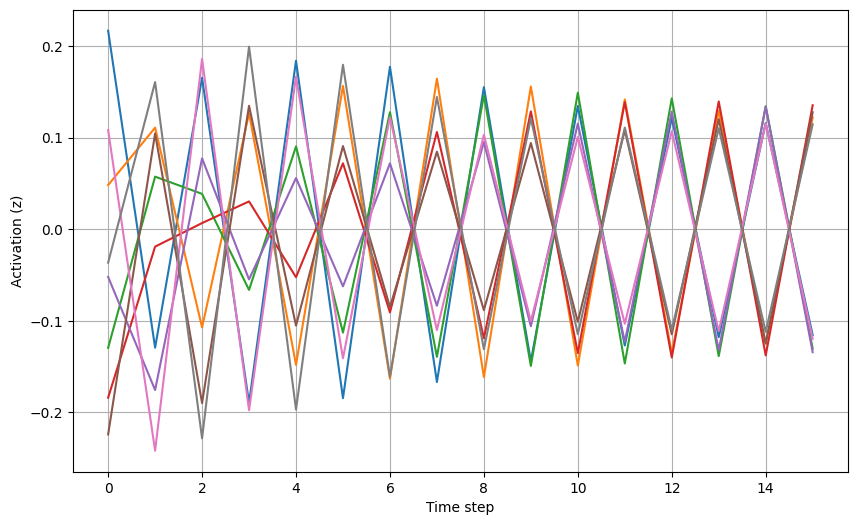

In [7]:
import numpy as np
import matplotlib.pyplot as plt
# import scienceplots

# plt.style.use(['science','bright'])
# plt.style.use(['science', 'std-colors'])
# plt.rcParams.update({'figure.dpi': '150'})
# mcolors = plt.rcParams['axes.prop_cycle'].by_key()['color']
# import matplotlib as mpl

# plt.style.use(['no-latex']) 



def evolve_FDM(z0, nt=50, U=1.0, D=1.0, dt=1.0, dx=1.0, normalize=True, BC="free"):

    
    NN = len(z0)
    traj = np.zeros((nt+1, NN))
    z = z0.copy().astype(float)

    if normalize:
        z /= np.sum(np.abs(z))

    traj[0, :] = z

    # -----------------------------------------------------------------
    # Build the forward Euler operator matrix W
    # -----------------------------------------------------------------
    r = D * dt / dx**2
    s = U * dt / (2 * dx)

    W = np.zeros((NN, NN))

    # interior coefficients
    for i in range(1, NN-1):
        W[i, i-1] = s + r
        W[i, i]   = 1 - 2*r
        W[i, i+1] = -s + r

    # ----- Boundary conditions -----
    if BC == "periodic":
        W[0, 0] = 1 - 2*r
        W[0, 1] = -s + r
        W[0, -1] = s + r

        W[-1, -1] = 1 - 2*r
        W[-1, -2] = s + r
        W[-1, 0] = -s + r

    elif BC == "free":
        W[0, 0] = 1 - r - s
        W[0, 1] = r + s

        W[-1, -1] = 1 - r + s
        W[-1, -2] = r - s

    elif BC == "zero":
        # zero Dirichlet BCs
        W[0, :] = 0.0
        W[-1, :] = 0.0

    elif BC == "neural":
        W[0, 0] = 1 - 2*r
        W[0, 1] = -s + r

        W[-1, -1] = 1 - 2*r
        W[-1, -2] = s + r

    else:
        raise ValueError("Invalid BC type.")


    for n in range(1, nt+1):
        z =  W @ z
        if normalize:
            z /= np.sum(np.abs(z))
        traj[n, :] = z

    return traj

# ---- Example usage ----
NN = 8
NL = 14 #total-2
np.random.seed(25)

z0 = 2.0 * np.random.rand(NN) - 1.0

# traj = advection_diffusion_trajectory(z0, nt=NL)
traj_ex= evolve_FDM(z0, nt=NL+1, BC="periodic", normalize=True)

# ---- Plot trajectories ----
plt.figure(figsize=(10, 6))
for i in range(NN):
    plt.plot(range(NL+2), traj_ex[:, i], label=f'z[{i}]')
plt.xlabel("Time step")
plt.ylabel("Activation (z)" )
# plt.title("Neural trajectories under advection-diffusion evolution")
plt.grid(True)
plt.show()


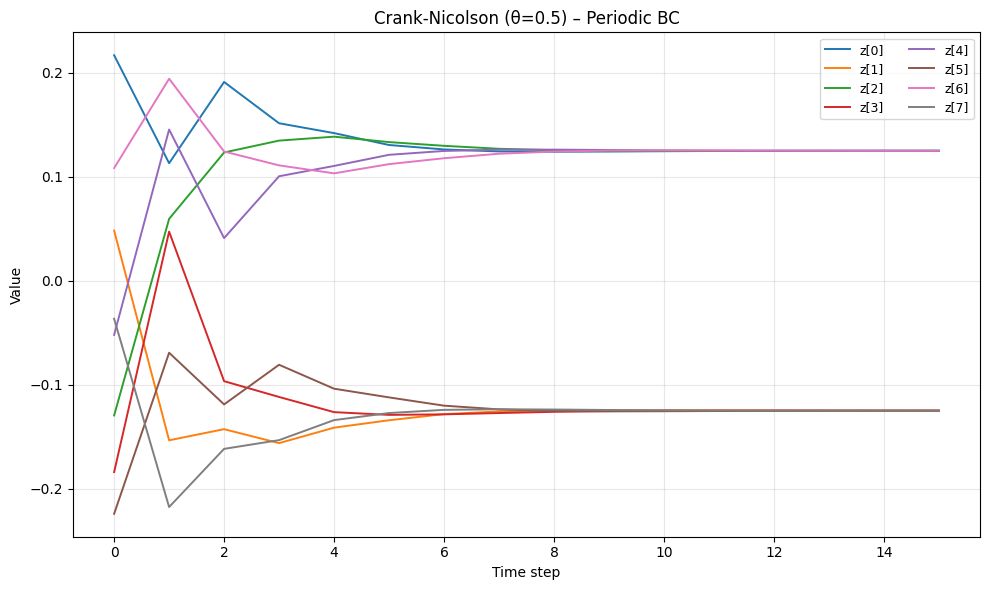

In [8]:


def evolve_crank_nicolson(z0, nt=50, U=1.0, D=1.0, dt=1.0, dx=1.0, 
                         normalize=True, BC="periodic", theta=0.5):
    """
    theta = 0.5  → Crank-Nicolson (recommended)
    theta = 1.0  → fully implicit (backward Euler)
    theta = 0.0  → fully explicit (forward Euler - your original)
    """
    NN = len(z0)
    traj = np.zeros((nt+1, NN))
    z = z0.copy().astype(float)
    
    if normalize:
        z /= np.sum(np.abs(z))
    
    traj[0, :] = z

    r = D * dt / dx**2
    s = U * dt / (2 * dx)

    # Build matrices A (left) and B (right)
    A = np.zeros((NN, NN))
    B = np.zeros((NN, NN))

    for i in range(NN):
        # Common diagonal
        A[i,i] = 1 + theta * 2 * r
        B[i,i] = 1 - (1-theta) * 2 * r

    for i in range(1, NN-1):
        # off-diagonals
        A[i, i-1] = theta * (s + r)
        A[i, i+1] = theta * (-s + r)
        
        B[i, i-1] = -(1-theta) * (s + r)
        B[i, i+1] = -(1-theta) * (-s + r)

    # Boundary conditions
    if BC == "periodic":
        # Left boundary
        A[0,0]   = 1 + theta * 2 * r
        A[0,1]   = theta * (-s + r)
        A[0,-1]  = theta * (s + r)
        
        B[0,0]   = 1 - (1-theta) * 2 * r
        B[0,1]   = -(1-theta) * (-s + r)
        B[0,-1]  = -(1-theta) * (s + r)

        # Right boundary (same as left due to periodicity)
        A[-1,-1] = A[0,0]
        A[-1,-2] = A[0,1]
        A[-1,0]  = A[0,-1]
        
        B[-1,-1] = B[0,0]
        B[-1,-2] = B[0,1]
        B[-1,0]  = B[0,-1]

    elif BC == "free":
        # Simplified Neumann-like (reflecting)
        A[0,0]   = 1 + theta * r
        A[0,1]   = theta * (r + s)
        B[0,0]   = 1 - (1-theta) * r
        B[0,1]   = -(1-theta) * (r + s)

        A[-1,-1] = 1 + theta * r
        A[-1,-2] = theta * (r - s)
        B[-1,-1] = 1 - (1-theta) * r
        B[-1,-2] = -(1-theta) * (r - s)

    # We solve A @ z_new = B @ z_old each step
    from scipy.linalg import solve

    for n in range(1, nt+1):
        rhs = B @ z
        z_new = solve(A, rhs)
        
        if normalize:
            z_new /= np.sum(np.abs(z_new))
            
        z = z_new
        traj[n, :] = z

    return traj


# -----------------------------
# Example usage
# -----------------------------
NN = 8
NL = 14
np.random.seed(25)

z0 = 2.0 * np.random.rand(NN) - 1.0

traj_cn = evolve_crank_nicolson(z0, nt=NL+1, U=1.0, D=1.0, dt=1.0, dx=1.0,
                            BC="periodic", normalize=True, theta=0.5)

# Plot
plt.figure(figsize=(10, 6))
for i in range(NN):
    plt.plot(range(NL+2), traj_cn[:, i], label=f'z[{i}]', lw=1.4)
plt.xlabel("Time step")
plt.ylabel("Value")
plt.title("Crank-Nicolson (θ=0.5) – Periodic BC")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

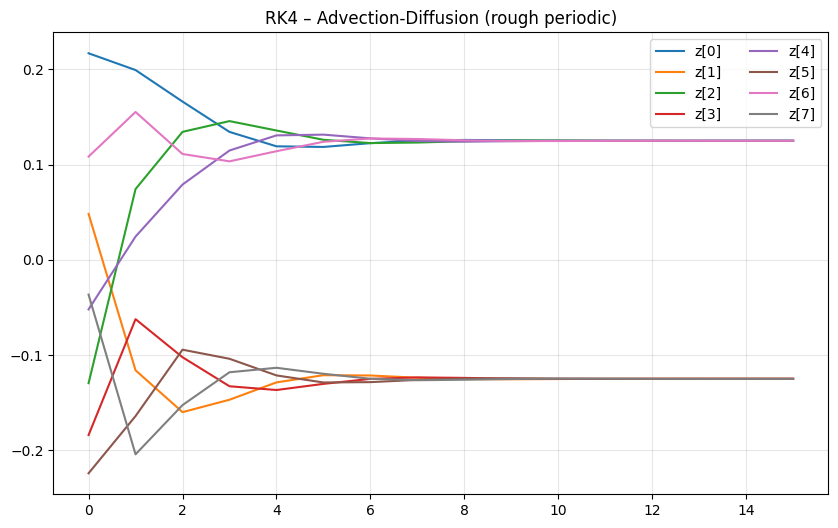

In [9]:
def advection_diffusion_rhs(z, U, D, dx):
    dz_dx   = (np.roll(z, -1) - np.roll(z, 1)) / (2 * dx)
    d2z_dx2 = (np.roll(z, -1) - 2*z + np.roll(z, 1)) / dx**2
    return -U * dz_dx + D * d2z_dx2



def evolve_rk4(z0, nt=50, U=1.0, D=1.0, dt=1.0, dx=1.0, normalize=True):
    z = z0.copy().astype(float)
    if normalize:
        z /= np.sum(np.abs(z))
    
    traj = np.zeros((nt+1, len(z)))
    traj[0] = z
    
    for n in range(nt):
        k1 = advection_diffusion_rhs(z,           U, D, dx)
        k2 = advection_diffusion_rhs(z + dt/2*k1, U, D, dx)
        k3 = advection_diffusion_rhs(z + dt/2*k2, U, D, dx)
        k4 = advection_diffusion_rhs(z + dt*k3,   U, D, dx)
        
        z += dt/6 * (k1 + 2*k2 + 2*k3 + k4)
        
        if normalize:
            z /= np.sum(np.abs(z))
            
        traj[n+1] = z
    
    return traj


# Quick test
traj_rk4 = evolve_rk4(z0, nt=NL+1, U=1.0, D=1.0, dt=1.0, dx=1.0, normalize=True)

plt.figure(figsize=(10, 6))
for i in range(NN):
    plt.plot(range(NL+2), traj_rk4[:, i], label=f'z[{i}]')
plt.title("RK4 – Advection-Diffusion (rough periodic)")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.show()

In [10]:
# =============================================================
# PARAMETERS (equivalent to chain.param + chain.inp)
# # =============================================================
# NN = 8     # neurons per layer
# NL = 16    # number of layers  (except input and output)
NR = 1          # realizations (from chain.inp)

nw =   6   
w0, wamp0 = 0.0, 0.10
b0, bamp0 = 0.0, 0.0
g0 = 0.01        # random perturbation amplitude
pblend = 1.0    # weight between tanh and ReLU (1=tanh, 0=ReLU)
normalize = True

# =============================================================
# ACTIVATION FUNCTIONS
# =============================================================
def relu(x, p=1.0):
    return p * np.maximum(0.0, x)

def activation(x, p=1.0):
    return p * np.tanh(x) + (1 - p) * relu(x)


def linear_activation(x):
    return x
# =============================================================
# BUILD GAUSSIAN KERNEL WEIGHTS
# =============================================================
def build_weights(nw_type, NN, NL, w0=0.0, wamp0=0.1, g0=0.0):
    """
    Returns W[l, m, n] weight array for a chain with NL+2 layers and NN neurons.
    nw_type:
        1 - Identity
        2 - Gaussian kernel with random diagonal
        3 - Random uniform
        4 - Random Gaussian
        5 - Ising spins (-0.5 or +0.5)
    """
    W = np.zeros((NL+2, NN, NN))
    
    if nw_type == 1:
        # Identity weights
        for l in range(NL+2):
            W[l] = np.eye(NN)
            
    elif nw_type == 2:
        # Gaussian kernel with optional random diagonal scaling
        sigma = NN / 4.0
        gau = g0 * (2.0 * np.random.rand(NN) - 1.0)


        for l in range(NL+2):
            for n in range(NN):
                for m in range(NN):
                    dist = abs(n - m) / sigma
                    W[l, m, n] = gau[n] * np.exp(-0.5 * dist**2) / sigma

                    
    elif nw_type == 3:
        # Random uniform across neurons, same across layers
        W0_layer = w0 + wamp0 * (2.0 * np.random.rand(NN, NN) - 1.0)
        for l in range(NL+2):
            W[l] = W0_layer.copy()
            
    elif nw_type == 4:
        # Random Gaussian (Box-Muller)
        for l in range(NL+2): 
            u1 = np.random.rand(NN, NN)
            u2 = np.random.rand(NN, NN)
            W[l] = w0 + wamp0 * np.sqrt(-2.0 * np.log(u1)) * np.cos(2 * np.pi * u2)
            
    elif nw_type == 5:
        # Ising model: -0.5 or +0.5 randomly
        for l in range(NL+2):
            W[l] = np.where(np.random.rand(NN, NN) > 0.5, 0.5, -0.5)
    
    elif nw_type == 6:  # TDM periodic
        for l in range(NL+2):
            for n in range(NN):      # target neuron (column)
                for m in range(NN):  # source neuron (row)
                    if m == n:
                        W[l, m, n] = -1      # diagonal
                    elif m == n - 1:
                        W[l, m, n] = 0.5    # below diagonal
                    elif m == n + 1:
                        W[l, m, n] = 3/2    # above diagonal
            # --- periodic wrap-around connections ---
            W[l, 0, NN-1] = 3/2    # first row connects to last column
            W[l, NN-1, 0] = 0.5    # last row connects to first column

    else:
        raise ValueError("nw_type must be 1..6")
        
    return W


# =============================================================
# MAIN SIMULATION
# =============================================================
W = build_weights(nw, NN, NL, g0=g0)
B = np.zeros((NL+2, NN))
zave = np.zeros((NL+2, NN))
znorm_all = np.zeros((NR, NL+2))
np.random.seed(25)


for ir in range(NR):
    # Random input layer in [-1, 1]
    z = np.zeros((NL+2, NN))
    z[0, :] = 2.0 * np.random.rand(NN) - 1.0

    # Normalize input
    if normalize:
        z[0, :] /= np.sum(np.abs(z[0, :]))

    # ---- forward propagation ----
    for l in range(NL+1):

        # Standard kernel propagation (your original code)
        zarg = W[l, :, :] @ z[l,:].T - B[l, :]
        z[l+1, :] = activation(zarg, pblend)
        # z[l+1, :] = linear_activation(zarg)


        #  Normalize (L1)
        if normalize:
            znorm = np.sum(np.abs(z[l+1, :]))
            z[l+1, :] /= znorm
        znorm_all[ir, l] = np.sum(np.abs(z[l+1, :]))


    # accumulate layer averages across realizations
    zave += z


# =============================================================
# AVERAGES
# =============================================================
zave /= NR
mean_norm = np.mean(znorm_all, axis=0)



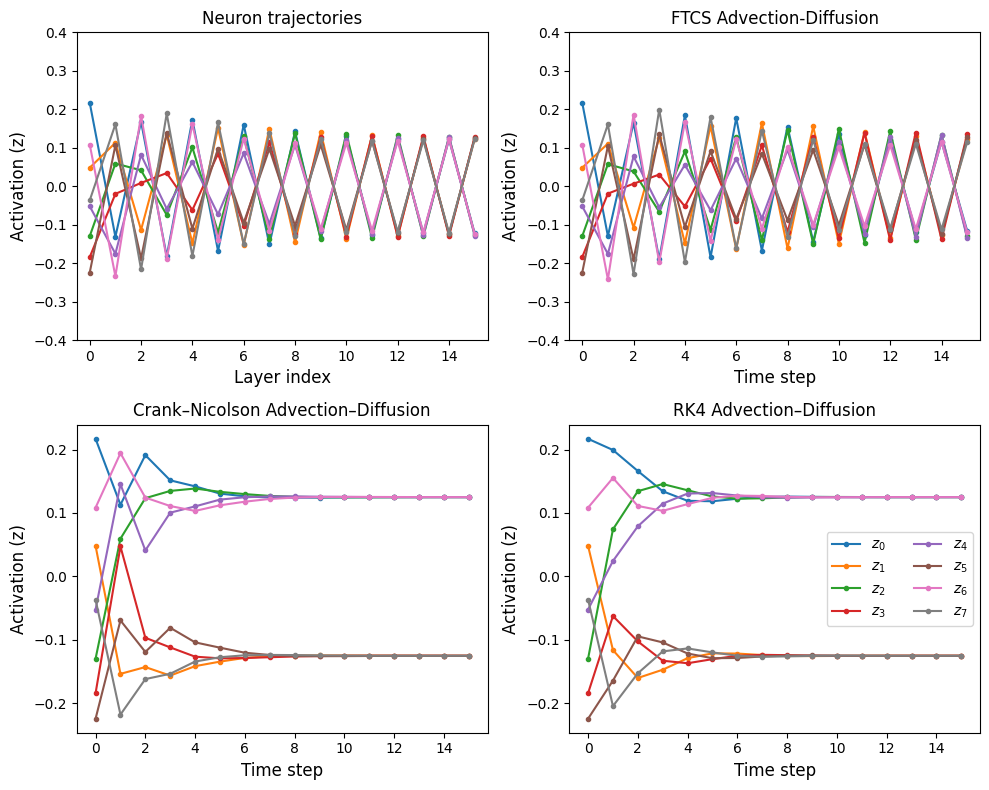

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=False)
axs = axs.flatten()  # IMPORTANT

# ---------------------------------------------------
# 0. Finite Difference trajectories
for i in range(NN):
    axs[1].plot(range(NL+2), traj_ex[:, i], '.-', label=f'z[{i}]')

axs[1].set_xlabel("Time step", fontsize=12)
axs[1].set_ylabel("Activation (z)", fontsize=12)
axs[1].set_xlim([-0.5, 15.5])
axs[1].set_ylim([-0.4, 0.4])
axs[1].set_title("FTCS Advection-Diffusion")
axs[1].grid(False)

# ---------------------------------------------------
# 1. Neuron trajectories (mean activations)
for n in range(NN):
    axs[0].plot(range(zave.shape[0]), zave[:, n], '.-', label=f'Neuron {n}')

axs[0].set_xlabel("Layer index", fontsize=12)
axs[0].set_ylabel("Activation (z)", fontsize=12)
axs[0].set_xlim([-0.5, 15.5])
axs[0].set_ylim([-0.4, 0.4])
axs[0].set_title("Neuron trajectories")
axs[0].grid(False)
# axs[1].legend(fontsize='medium', ncol=4, loc='upper center',
#               bbox_to_anchor=(0.5, -0.15))

# ---------------------------------------------------
# 2. CN scheme trajectories
for i in range(NN):
    axs[2].plot(range(NL+2), traj_cn[:, i], '.-' ,label=f'z_{i}')
axs[2].set_xlabel("Time step", fontsize=12)
axs[2].set_ylabel("Activation (z)", fontsize=12)
axs[2].set_title("Crank–Nicolson Advection–Diffusion")
# axs[2].legend(ncol=2)

# ---------------------------------------------------
# 3. RK4 scheme trajectories
for i in range(NN):
    axs[3].plot(range(NL+2), traj_rk4[:, i],  '.-', label=fr'$z_{i}$')
axs[3].set_xlabel("Time step", fontsize=12)
axs[3].set_ylabel("Activation (z)", fontsize=12)
axs[3].set_title("RK4 Advection–Diffusion")
axs[3].legend(ncol=2)

# ---------------------------------------------------
fig.tight_layout()
plt.savefig('./figs/fdm_vs_neural_evol.pdf')
plt.show()
